# MedRegA Fine-tune (QLoRA) — notebook RIÊNG

Train Gemma định vị u gan, **kernel sạch** (không vướng VRAM notebook chính). Chạy lần lượt từ trên xuống. Adapter lưu ở Drive `medrega/model/checkpoints/qlora_liver_v1`.

## 0. Môi trường

In [1]:
# === [Chạy đầu tiên] Dọn VRAM: giết kernel "ma" còn ôm GPU sau restart ===
import os, subprocess, torch
if torch.cuda.is_available():
    torch.cuda.init(); _ = torch.zeros(1, device="cuda")   # chạm GPU để kernel hiện tại hiện trong nvidia-smi
my_pid = os.getpid()
raw = subprocess.run(["nvidia-smi", "--query-compute-apps=pid", "--format=csv,noheader"],
                     capture_output=True, text=True).stdout
pids = sorted({int(x) for x in raw.split() if x.strip().isdigit()})
print("PID kernel HIỆN TẠI (giữ):", my_pid, "| PID đang dùng GPU:", pids)
if my_pid in pids:
    ma = [p for p in pids if p != my_pid]
    for p in ma:
        os.system(f"kill -9 {p}"); print("  -> đã giết kernel ma:", p)
    print("Sạch." if ma else "Không có kernel ma nào.")
else:
    print("[THẬN TRỌNG] Không thấy PID hiện tại trong list -> KHÔNG tự kill (kill tay nếu chắc).")

PID kernel HIỆN TẠI (giữ): 6964 | PID đang dùng GPU: [6964]
Không có kernel ma nào.


In [2]:
!nvidia-smi
import torch
print("CUDA:", torch.cuda.is_available())

Mon Jun 29 13:58:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P0             50W /  400W |     506MiB /  40960MiB |      9%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
# === Cài thư viện thiếu trên Colab (chạy 1 lần đầu session) ===
# bitsandbytes: nén 4-bit | accelerate: đặt model lên GPU (device_map="auto")
%pip install -q -U bitsandbytes accelerate peft torchao


In [4]:
import os, json, re, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score

import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

print("Import xong | CUDA:", torch.cuda.is_available())

Import xong | CUDA: True


## 1. Cấu hình

In [5]:
MODEL_ID = "google/gemma-4-E4B-it"    # thay gemma-3n-e4b-it
USE_MOCK    = False           # False: chạy model thật (cần GPU); True: chạy thử không cần model
DATA_DIR    = None            # gán ở cell dữ liệu = data_liver
COORD_SCALE = 1000            # toạ độ box [0,1000)
N_SAMPLES   = 5               # số lần sample đo nhất quán không gian (Hướng 1)
IOU_CORRECT = 0.5             # ngưỡng IoU coi là đúng
EVAL_LIMIT  = None              # số ảnh test chạy ở phần đánh giá (None = hết)
MAX_NEW_TOKENS = 192           # số token tối đa model sinh (box ngắn, 64 đủ) — dùng ở cell kiểm tra cuối
SEED        = 0
RUN_NAME    = "gemma4_v4_binary_loss"   # <<< folder ckpt + tên JSON lần này (BCE-head). ĐỔI mỗi lần train MỚI
# --- Núm loss chống LƯỜI DETECT (recall thấp). λ = núm điều khiển DUY NHẤT: FP bùng -> HẠ λ ---
W_POS, W_NEG = 1.5, 1.0       # CE-weight gần trung tính (BCE-head mới là cơ chế chính)
LAMBDA_BCE   = 2.0            # trọng số BCE-head (phạt thẳng quyết định detect)
BCE_POS_W    = 1.5            # trọng số vế DƯƠNG trong BCE (kéo recall; vế âm = van an toàn FP)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print("DEVICE:", DEVICE, "| USE_MOCK:", USE_MOCK)

LOAD_IN_4BIT = True   # notebook train -> luon 4-bit (QLoRA)

DEVICE: cuda | USE_MOCK: False


## 2. Dữ liệu (đọc data_liver từ Drive + split train/cal/test)

In [6]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Ví dụ đường dẫn lưu/đọc data trên Drive:
import os
DRIVE_DIR = "/content/drive/MyDrive/Colab Notebooks/medrega/data"   # đổi theo ý mày
os.makedirs(DRIVE_DIR, exist_ok=True)
print("Drive đã mount. Lưu data tại:", DRIVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive đã mount. Lưu data tại: /content/drive/MyDrive/Colab Notebooks/medrega/data


In [7]:
# === Lấy data_liver_multi (1238 mẫu) từ Drive ===
import os, zipfile, glob
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/medrega/data_multi_v3/data_liver"
zip_path = "/content/drive/MyDrive/Colab Notebooks/medrega/data_multi_v3/data_liver_multi_v3.zip"

if not os.path.exists(os.path.join(DATA_DIR, "data.jsonl")):
    os.makedirs(DATA_DIR, exist_ok=True)
    print("Giải nén ->", DATA_DIR)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(DATA_DIR)
else:
    print("Đã có data_multi -> dùng luôn.")

n_row = sum(1 for _ in open(os.path.join(DATA_DIR, "data.jsonl"), encoding="utf-8"))
print("DATA_DIR =", DATA_DIR, "| jsonl:", n_row)   # phải in 1238

Đã có data_multi -> dùng luôn.
DATA_DIR = /content/drive/MyDrive/Colab Notebooks/medrega/data_multi_v3/data_liver | jsonl: 1211


In [8]:
# === Đọc data.jsonl + chia train/cal/test THEO BỆNH NHÂN (không lộ dữ liệu) ===
# train: để fine-tune | cal: hiệu chỉnh ngưỡng (Hướng 1) | test: đánh giá cuối.
import json, numpy as np

rows = [json.loads(l) for l in open(os.path.join(DATA_DIR, "data.jsonl"), encoding="utf-8")]

rng = np.random.default_rng(SEED)                    # SEED từ cell config (Section 2)
pids = sorted({r["patient_id"] for r in rows}); rng.shuffle(pids)
n = len(pids)
n_tr, n_ca = int(n * 0.6), int(n * 0.2)              # 60% train / 20% cal / 20% test
tr = set(pids[:n_tr]); ca = set(pids[n_tr:n_tr + n_ca])
dataset = {
    "train": [r for r in rows if r["patient_id"] in tr],
    "cal":   [r for r in rows if r["patient_id"] in ca],
    "test":  [r for r in rows if r["patient_id"] not in tr and r["patient_id"] not in ca],
}
OUT_DIR = DATA_DIR

# kiểm tra không lộ dữ liệu: 3 tập không trùng bệnh nhân
_s = {k: {r["patient_id"] for r in v} for k, v in dataset.items()}
assert not (_s["train"] & _s["cal"]) and not (_s["train"] & _s["test"]) and not (_s["cal"] & _s["test"])
print("Tổng mẫu:", len(rows),
      "| dương:", sum(r["label"] == "tumor" for r in rows),
      "| âm:", sum(r["label"] == "none" for r in rows))
print("Split (theo bệnh nhân):", {k: len(v) for k, v in dataset.items()})
print("Bệnh nhân:", {k: len(s) for k, s in _s.items()}, "-> không trùng (OK)")

Tổng mẫu: 1211 | dương: 558 | âm: 653
Split (theo bệnh nhân): {'train': 723, 'cal': 233, 'test': 255}
Bệnh nhân: {'train': 78, 'cal': 26, 'test': 27} -> không trùng (OK)


## 3. Model 4-bit + hàm format

In [9]:
# === [KHÔI PHỤC] Dựng lại model từ *_trainable.pt — NẠP CHẮC CHẮN (remap key + hard-fail) ===
# v1 ra ≈ base vì peft/transformers version khác -> tên key LoRA lệch -> rơi vào missing_keys im lặng
# (assert cũ chỉ check unexpected). Bản này remap key (.default infix) + bắt buộc lora_B != 0 mới merge.
# Chạy SAU split. SKIP cell `load`. Chạy 1 lần -> tự lưu model đủ -> lần sau load thẳng bằng cell load-merged.
RUN_OLD_CKPT = True
if RUN_OLD_CKPT:
    import os, torch
    from transformers import AutoModelForImageTextToText, AutoProcessor
    from peft import LoraConfig, get_peft_model
    from huggingface_hub import login
    CKPT_DIR = "/content/drive/MyDrive/Colab Notebooks/medrega/model/checkpoints"
    RUN_NAME = "gemma4_v4_binary_loss"
    CKPT_RUN = os.path.join(CKPT_DIR, RUN_NAME)
    PT = os.path.join(CKPT_RUN, "best_trainable.pt")     # đổi epochN_trainable.pt nếu muốn ckpt khác
    HF_CACHE = "/content/hf_cache"; os.makedirs(HF_CACHE, exist_ok=True)
    MEDREGA_ROOT = os.path.dirname(os.path.dirname(CKPT_DIR))

    def _hf_token():
        try:
            from google.colab import userdata
            if userdata.get("HF_TOKEN"): return userdata.get("HF_TOKEN")
        except Exception: pass
        env = os.path.join(MEDREGA_ROOT, "secrets.env")
        if os.path.exists(env):
            for ln in open(env, encoding="utf-8"):
                ln = ln.strip()
                if ln.startswith("HF_TOKEN") and "=" in ln:
                    return ln.split("=", 1)[1].strip().strip(chr(34)).strip(chr(39))
        return os.environ.get("HF_TOKEN")
    try: login(token=_hf_token())
    except Exception as e: print("HF login warn:", e)

    # 1) base + cấu trúc Y HỆT train (LoRA r=32 + vision full-FT float)
    processor = AutoProcessor.from_pretrained(MODEL_ID, cache_dir=HF_CACHE)
    model = AutoModelForImageTextToText.from_pretrained(MODEL_ID, cache_dir=HF_CACHE,
                torch_dtype=torch.bfloat16, device_map={"": 0})
    model.enable_input_require_grads()
    lora = LoraConfig(r=32, lora_alpha=64, lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
        target_modules=r".*language_model.*\.(q_proj|k_proj|v_proj|o_proj|gate_proj|up_proj|down_proj)$")
    model = get_peft_model(model, lora)
    VIS_KEYS = ("vision_tower", "multi_modal", "projector", "embed_vision", "mm_proj")
    for nm, p in model.named_parameters():
        if any(k in nm.lower() for k in VIS_KEYS) and "lora" not in nm.lower() and p.dtype.is_floating_point:
            p.data = p.data.float(); p.requires_grad = True

    # 2) NẠP CHẮC: remap key (bỏ infix '.default' khác giữa version peft) + khớp shape
    sd  = torch.load(PT, map_location="cpu")
    msd = dict(model.named_parameters())
    def _norm(k): return k.replace(".default", "")       # peft đổi tên LoRA ở chỗ này giữa các version
    norm2real = {}
    for mk in msd: norm2real.setdefault(_norm(mk), mk)
    remap, miss = {}, []
    for sk, v in sd.items():
        rk = norm2real.get(_norm(sk))
        if rk is not None and tuple(msd[rk].shape) == tuple(v.shape):
            remap[rk] = v
        else:
            miss.append(sk)
    model.load_state_dict(remap, strict=False)
    lb = sum(float(p.detach().abs().sum()) for n, p in model.named_parameters() if "lora_B" in n)
    print(f"Nạp {len(remap)}/{len(sd)} key đã-train | KHÔNG khớp: {len(miss)} | tổng |lora_B| = {lb:.2f}")
    if miss:
        print("  Key KHÔNG khớp (5 vd):", miss[:5]); print("  Model key mẫu:", list(msd)[:3])
    assert len(miss) == 0, f"{len(miss)} trọng số đã-train KHÔNG nạp được -> DỪNG (gửi list 'miss' để remap đúng)."
    assert lb > 0, "tổng |lora_B| = 0 -> adapter CHƯA nạp -> DỪNG (đừng merge ra base)."

    # 3) merge + LƯU đủ (lần này không sập) -> lần sau load thẳng
    model = model.merge_and_unload()
    model.save_pretrained(CKPT_RUN, safe_serialization=True); processor.save_pretrained(CKPT_RUN)
    model.config.use_cache = True; model.eval()
    print("KHÔI PHỤC OK + đã lưu model hoàn chỉnh:", CKPT_RUN, "| VRAM:", round(torch.cuda.memory_allocated()/1e9,1), "GB")
    print("-> train/selck/mergesave/load tự SKIP. Chạy fmt/util/sec8/sec9/metrics/sec11.")
else:
    print("RUN_OLD_CKPT=False -> bỏ qua (sẽ train model mới).")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

Nạp best_trainable.pt | unexpected=0 (PHẢI = 0)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KHÔI PHỤC + LƯU model hoàn chỉnh xong: /content/drive/MyDrive/Colab Notebooks/medrega/model/checkpoints/gemma4_v4_binary_loss | VRAM: 16.2 GB


In [10]:
# === Tải model Gemma BF16 + processor (A100, KHÔNG 4-bit) ===
if globals().get("RUN_OLD_CKPT", False):
    print("RUN_OLD_CKPT=True -> BỎ QUA tải base Gemma (dùng model từ cell khôi phục/load-cũ).")
else:
    import os, torch
    MEDREGA_ROOT = os.path.dirname(DRIVE_DIR.rstrip("/"))
    HF_CACHE = "/content/hf_cache"
    CKPT_DIR = os.path.join(MEDREGA_ROOT, "model", "checkpoints")
    os.makedirs(HF_CACHE, exist_ok=True); os.makedirs(CKPT_DIR, exist_ok=True)

    def _hf_token():
        try:
            from google.colab import userdata
            if userdata.get("HF_TOKEN"): return userdata.get("HF_TOKEN")
        except Exception:
            pass
        env = os.path.join(MEDREGA_ROOT, "secrets.env")
        if os.path.exists(env):
            for line in open(env, encoding="utf-8"):
                line = line.strip()
                if line.startswith("HF_TOKEN") and "=" in line:
                    return line.split("=", 1)[1].strip().strip(chr(34)).strip(chr(39))
        return os.environ.get("HF_TOKEN")

    from huggingface_hub import login
    login(token=_hf_token())

    processor = AutoProcessor.from_pretrained(MODEL_ID, cache_dir=HF_CACHE)
    model = AutoModelForImageTextToText.from_pretrained(
        MODEL_ID, cache_dir=HF_CACHE, torch_dtype=torch.bfloat16, device_map={"": 0})
    model.eval()
    print("Đã tải model BF16:", MODEL_ID, "| VRAM:", round(torch.cuda.memory_allocated()/1e9, 1), "GB")

RUN_OLD_CKPT=True -> BỎ QUA tải base Gemma (dùng model từ cell khôi phục/load-cũ).


In [11]:
# Định dạng record -> input Gemma + AUGMENT (on-the-fly, CHỈ train) + build_train_example | MULTI-BOX
from PIL import Image
import os, math, random as _rnd
import numpy as np

INSTRUCT_PROMPT_TRAIN = """You are a medical imaging assistant. This abdominal CT image may or may not contain liver tumors (abnormal masses or lesions inside the liver). There may be ONE, SEVERAL, or NO tumors. Examine the liver region carefully.
Coordinate system: treat the image as a 1000x1000 grid. (0,0) is the TOP-LEFT corner and (1000,1000) is the BOTTOM-RIGHT corner. All coordinates are integers from 0 to 1000.
Respond with EXACTLY ONE of these two options and nothing else:
1. If one or more tumors are present, give a bounding box for EACH tumor: <ref>liver tumor</ref><box>[[x1, y1, x2, y2], [x1, y1, x2, y2], ...]</box>
2. If there is no tumor: No liver tumor is found."""

PROMPT_2OPT = INSTRUCT_PROMPT_TRAIN
PROMPT_3OPT = INSTRUCT_PROMPT_TRAIN.replace(
    "Respond with EXACTLY ONE of these two options and nothing else:",
    "Respond with EXACTLY ONE of these three options and nothing else:") + \
    "\n3. If you are genuinely UNSURE whether a tumor is present: Uncertain."
INSTRUCT_PROMPT_TEST = PROMPT_2OPT

AUGMENT = True          # bật augment khi train (val/test gọi với do_augment=False)

def load_image(rec, root=None):
    root = root or globals().get("DATA_DIR") or globals().get("OUT_DIR") or "."
    path = rec["image_path"]
    if not os.path.isabs(path):
        path = os.path.join(root, path)
    return Image.open(path).convert("RGB")

def augment(img, boxes, p=0.9):
    """MULTI-BOX. boxes: list [x1,y1,x2,y2] thang [0,COORD_SCALE) (rỗng = ca âm).
       Áp CÙNG affine cho mọi box; bỏ box ra ngoài khung. Hết box -> giữ ảnh+boxes GỐC.
       Dịch ±18% / xoay ±12° / scale ±10% / sáng nhẹ. KHÔNG flip/xoay90 (CT gan)."""
    if _rnd.random() > p:
        return img, boxes
    W, H = img.size
    angle = _rnd.uniform(-12, 12); scale = _rnd.uniform(0.9, 1.1)
    dx = _rnd.uniform(-0.18, 0.18) * W; dy = _rnd.uniform(-0.18, 0.18) * H
    cx, cy = W / 2.0, H / 2.0
    a = math.radians(angle); cos, sin = math.cos(a), math.sin(a)
    ia, ib = cos / scale, sin / scale
    ic = -ia * (cx + dx) - ib * (cy + dy) + cx
    id_, ie = -sin / scale, cos / scale
    if_ = -id_ * (cx + dx) - ie * (cy + dy) + cy
    img2 = img.transform((W, H), Image.AFFINE, (ia, ib, ic, id_, ie, if_),
                         resample=Image.BILINEAR, fillcolor=(0, 0, 0))
    arr = np.asarray(img2).astype(np.float32) * _rnd.uniform(0.85, 1.15)
    img2 = Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))
    if not boxes:
        return img2, boxes
    def fwd(x, y):
        return (scale * (cos * (x - cx) - sin * (y - cy)) + cx + dx,
                scale * (sin * (x - cx) + cos * (y - cy)) + cy + dy)
    new_boxes = []
    for box in boxes:
        px = [box[0] / COORD_SCALE * W, box[2] / COORD_SCALE * W]
        py = [box[1] / COORD_SCALE * H, box[3] / COORD_SCALE * H]
        cs = [fwd(x, y) for x in px for y in py]
        xs = [c[0] for c in cs]; ys = [c[1] for c in cs]
        nx1, ny1, nx2, ny2 = max(0, min(xs)), max(0, min(ys)), min(W, max(xs)), min(H, max(ys))
        if nx2 - nx1 < 4 or ny2 - ny1 < 4:
            continue                                   # box này ra ngoài -> bỏ riêng box này
        new_boxes.append([int(nx1 / W * COORD_SCALE), int(ny1 / H * COORD_SCALE),
                          int(nx2 / W * COORD_SCALE), int(ny2 / H * COORD_SCALE)])
    if not new_boxes:
        return img, boxes                              # tất cả ra ngoài -> giữ GỐC (không đổi nhãn)
    return img2, new_boxes

def to_messages(rec, with_answer, prompt):
    msgs = [{"role": "user", "content": [
        {"type": "image", "image": load_image(rec)},
        {"type": "text",  "text": prompt}]}]
    if with_answer:
        msgs.append({"role": "model",
                     "content": [{"type": "text", "text": rec["conversations"][-1]["value"]}]})
    return msgs

def build_infer_inputs(rec, processor, device=None, prompt=None):
    """INFERENCE (eval): KHÔNG augment. prompt riêng cho conf_self."""
    inputs = processor.apply_chat_template(
        to_messages(rec, False, prompt or INSTRUCT_PROMPT_TEST),
        add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt")
    return inputs.to(device) if device else inputs

def _answer_from_boxes(boxes):
    if not boxes:
        return "No liver tumor is found."
    inner = ", ".join(f"[{b[0]}, {b[1]}, {b[2]}, {b[3]}]" for b in boxes)
    return f"<ref>liver tumor</ref><box>[{inner}]</box>"

def build_train_example(rec, processor, do_augment=None):
    """TRAIN multi-box: AUGMENT ảnh+boxes on-the-fly. do_augment=None -> AUGMENT global (train=True, val=False).
       Loss CHỈ trên token đáp án. _is_pos cho W_POS weighting."""
    import torch
    do_augment = AUGMENT if do_augment is None else do_augment
    img = load_image(rec); boxes = list(rec.get("gt_boxes") or [])
    if do_augment:
        img, boxes = augment(img, boxes)
    ans = _answer_from_boxes(boxes)
    msgs_full = [{"role": "user", "content": [{"type": "image", "image": img},
                  {"type": "text", "text": INSTRUCT_PROMPT_TRAIN}]},
                 {"role": "model", "content": [{"type": "text", "text": ans}]}]
    full = processor.apply_chat_template(msgs_full, add_generation_prompt=False,
                  tokenize=True, return_dict=True, return_tensors="pt")
    prompt = processor.apply_chat_template(msgs_full[:1], add_generation_prompt=True,
                  tokenize=True, return_dict=True, return_tensors="pt")
    labels = full["input_ids"].clone()
    labels[:, :prompt["input_ids"].shape[1]] = -100
    out = dict(full); out["labels"] = labels
    out["_is_pos"] = torch.tensor([1.0 if boxes else 0.0])
    _first = (labels[0] != -100).nonzero()                  # vị trí token ĐẦU phần đáp án
    out["_detect_pos"] = torch.tensor([int(_first[0])])     # cho BCE-head (quyết định detect vs No)
    return out

print("Format MULTI-BOX + AUGMENT (train) sẵn sàng. AUGMENT =", AUGMENT)

Format MULTI-BOX + AUGMENT (train) sẵn sàng. AUGMENT = True


In [12]:
# === Hàm tiện ích — parse_box + IoU (cho cell kiểm tra cuối) ===
import re

def parse_box(text):
    """Đọc box từ text model -> [x1,y1,x2,y2]. None nếu model nói không có u / không có số.
       Xử lý: <box>[[x1,y1,x2,y2]]</box>, json {x,y,width,height} (xywh), hoặc 4 số đầu tiên."""
    t = str(text)
    # 1) model nói KHÔNG có u (và không kèm toạ độ) -> None (đúng cho ca âm)
    neg = re.search(r"no\b.{0,30}tumor|not\s.{0,20}found|cannot provide|no .{0,20}lesion", t, re.I)
    if neg and not re.search(r'"width"|"x"\s*:|<box>', t, re.I):
        return None
    # 2) json xywh: {"x":..,"y":..,"width":..,"height":..} -> đổi sang xyxy
    m = re.search(r'"x"\s*:\s*(\d+).*?"y"\s*:\s*(\d+).*?"width"\s*:\s*(\d+).*?"height"\s*:\s*(\d+)', t, re.S | re.I)
    if m:
        x, y, w, h = map(int, m.groups())
        return [x, y, x + w, y + h]
    # 3) lấy 4 số nguyên đầu tiên (bắt cả <box>[[...]]). Giả định x1,y1,x2,y2.
    nums = re.findall(r"\d+", t)
    if len(nums) >= 4:
        x1, y1, x2, y2 = map(int, nums[:4])
        if x2 > x1 and y2 > y1:
            return [x1, y1, x2, y2]
        return [x1, y1, x1 + abs(x2), y1 + abs(y2)]   # phòng khi lỡ là xywh
    return None

def iou(b1, b2):
    """IoU giữa 2 box [x1,y1,x2,y2]. None -> 0.0."""
    if b1 is None or b2 is None:
        return 0.0
    xa, ya = max(b1[0], b2[0]), max(b1[1], b2[1])
    xb, yb = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter = max(0, xb - xa) * max(0, yb - ya)
    a1 = max(0, b1[2] - b1[0]) * max(0, b1[3] - b1[1])
    a2 = max(0, b2[2] - b2[0]) * max(0, b2[3] - b2[1])
    u = a1 + a2 - inter
    return inter / u if u > 0 else 0.0

# test nhanh
assert parse_box("<ref>liver tumor</ref><box>[[10, 20, 110, 220]]</box>") == [10, 20, 110, 220]
assert parse_box('{"x": 150, "y": 150, "width": 120, "height": 100}') == [150, 150, 270, 250]
assert parse_box("No liver tumor is found.") is None
assert abs(iou([0, 0, 100, 100], [50, 50, 150, 150]) - 1/7) < 1e-6
print("parse_box + iou OK (đã test xywh + <box> + ca âm)")

# === MULTI-BOX utils (Phase: multi-box) ===
import numpy as np
from scipy.optimize import linear_sum_assignment

def parse_boxes(text):
    """Đọc TẤT CẢ box từ text model -> list [x1,y1,x2,y2]. [] nếu model nói không u / không số."""
    t = str(text)
    neg = re.search(r"no\b.{0,30}tumor|not\s.{0,20}found|no .{0,20}lesion", t, re.I)
    if neg and "[" not in t:
        return []
    boxes = []
    for m in re.findall(r"\[\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*\]", t):
        x1, y1, x2, y2 = map(int, m)
        if x2 > x1 and y2 > y1:
            boxes.append([x1, y1, x2, y2])
    return boxes

def match_boxes(preds, gts):
    """Hungarian match preds<->gts theo IoU (không theo thứ tự). Trả (matched_ious, n_pred, n_gt)."""
    if not preds or not gts:
        return [], len(preds), len(gts)
    M = np.zeros((len(preds), len(gts)))
    for i, p in enumerate(preds):
        for j, gv in enumerate(gts):
            M[i, j] = iou(p, gv)
    ri, ci = linear_sum_assignment(1 - M)
    return [float(M[r, c]) for r, c in zip(ri, ci)], len(preds), len(gts)

def box_metrics(preds, gts, thr=0.25):
    """Precision/recall/f1 + mean matched-IoU cho 1 lát (multi-box)."""
    mi, npd, ngt = match_boxes(preds, gts)
    hit = sum(v >= thr for v in mi)
    prec = hit / npd if npd else 0.0
    rec = hit / ngt if ngt else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    miou = float(np.mean(mi)) if mi else 0.0
    return {"prec": prec, "rec": rec, "f1": f1, "miou": miou, "n_pred": npd, "n_gt": ngt}

assert parse_boxes("<ref>liver tumor</ref><box>[[10, 20, 110, 220], [30, 40, 130, 240]]</box>") == [[10,20,110,220],[30,40,130,240]]
assert parse_boxes("No liver tumor is found.") == []
_mi, _np, _ng = match_boxes([[0,0,100,100]], [[50,50,150,150],[0,0,100,100]])
assert _np == 1 and _ng == 2 and max(_mi) == 1.0
print("parse_boxes + match_boxes (Hungarian) OK")


parse_box + iou OK (đã test xywh + <box> + ca âm)
parse_boxes + match_boxes (Hungarian) OK


## 4. Train QLoRA

In [13]:
import torch
seen = {}
for n, m in model.named_modules():
    t = type(m).__name__
    if t in ("Linear", "Gemma4ClippableLinear"):
        low = n.lower()
        if "vision" in low or "vit" in low: grp = "VISION"
        elif any(x in low for x in ["connector","projector","mm_proj","multi_modal","embed_vision","mmproj"]): grp = "CONNECTOR"
        elif "language" in low or "text" in low or "decoder" in low: grp = "LLM"
        else: grp = "?KHÁC"
        seen.setdefault((grp, t), n)
for (grp, t), ex in sorted(seen.items()):
    print(f"{grp:10} {t:24} | ví dụ: {ex}")

?KHÁC      Gemma4ClippableLinear    | ví dụ: model.audio_tower.layers.0.feed_forward1.ffw_layer_1
?KHÁC      Linear                   | ví dụ: model.audio_tower.subsample_conv_projection.input_proj_linear
LLM        Linear                   | ví dụ: model.language_model.layers.0.self_attn.q_proj
VISION     Gemma4ClippableLinear    | ví dụ: model.vision_tower.encoder.layers.0.self_attn.q_proj
VISION     Linear                   | ví dụ: model.vision_tower.patch_embedder.input_proj


In [14]:
if globals().get("RUN_OLD_CKPT", False):
    print("RUN_OLD_CKPT=True -> BỎ QUA cell train (đang EVAL model CŨ, không train lại).")
else:
    # === TRAIN: full-FT vision + LoRA LLM r=32 | W_POS + BCE-head (chống LƯỜI detect) | lưu MỌI epoch ===
    import torch, torch.nn.functional as F, bitsandbytes as bnb, os, random as _rnd
    from torch.utils.data import Dataset
    from peft import LoraConfig, get_peft_model
    from transformers import TrainingArguments, Trainer, TrainerCallback

    EPOCHS    = 5
    LR_LLM    = 2e-4
    LR_VISION = 1e-5
    GRAD_ACC  = 8
    W_POS     = globals().get("W_POS", 1.5)        # gần trung tính (cfg). BCE-head mới là cơ chế CHÍNH chống lười.
    W_NEG     = globals().get("W_NEG", 1.0)
    LAMBDA_BCE= globals().get("LAMBDA_BCE", 2.0)   # núm điều khiển DUY NHẤT — FP bùng thì HẠ
    BCE_POS_W = globals().get("BCE_POS_W", 1.5)    # trọng số vế dương trong BCE
    VIS_KEYS  = ("vision_tower", "multi_modal", "projector", "embed_vision", "mm_proj")
    CKPT_RUN  = os.path.join(CKPT_DIR, RUN_NAME)    # tên lần train từ cfg (RUN_NAME)
    os.makedirs(CKPT_RUN, exist_ok=True)
    BEST_PT   = os.path.join(CKPT_RUN, "best_trainable.pt")

    model.enable_input_require_grads()   # TẮT gradient_checkpointing (A100 dư VRAM) -> nhanh hơn ~25%
    lora = LoraConfig(r=32, lora_alpha=64, lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
        target_modules=r".*language_model.*\.(q_proj|k_proj|v_proj|o_proj|gate_proj|up_proj|down_proj)$")
    model = get_peft_model(model, lora); model.config.use_cache = False

    n_vis = 0
    for nm, p in model.named_parameters():
        if any(k in nm.lower() for k in VIS_KEYS) and "lora" not in nm.lower() and p.dtype.is_floating_point:
            p.data = p.data.float(); p.requires_grad = True; n_vis += p.numel()
    print(f"Full-FT vision: {n_vis/1e6:.1f}M | audio đóng băng")
    model.print_trainable_parameters()

    llm = [p for nm, p in model.named_parameters() if p.requires_grad and "lora" in nm.lower()]
    vis = [p for nm, p in model.named_parameters() if p.requires_grad and any(k in nm.lower() for k in VIS_KEYS)]
    print(f"LoRA-LLM {sum(p.numel() for p in llm)/1e6:.1f}M @{LR_LLM} | vision {sum(p.numel() for p in vis)/1e6:.1f}M @{LR_VISION}")
    optimizer = bnb.optim.PagedAdamW8bit([{"params": llm, "lr": LR_LLM}, {"params": vis, "lr": LR_VISION}])

    # --- Token QUYẾT ĐỊNH detect = token ĐẦU phần đáp án (post chat-template). IN KIỂM 20 mẫu (BẮT BUỘC) ---
    def _first_ans_tok(rec):
        ex  = build_train_example(rec, processor, do_augment=False)
        lbl = ex["labels"][0]; ids = ex["input_ids"][0]
        pos = int((lbl != -100).nonzero()[0])
        return pos, int(ids[pos])
    assert any("gt_boxes" in r for r in dataset["train"]), "data thiếu key gt_boxes (v3 phải có) -> kiểm prep_data_multi_v3"
    _posr = next((r for r in dataset["train"] if r.get("gt_boxes")), None)
    _negr = next((r for r in dataset["train"] if not r.get("gt_boxes")), None)
    assert _posr is not None and _negr is not None, "train split thiếu ca dương HOẶC âm -> không derive được detect/no token"
    DETECT_TOKEN_ID = _first_ans_tok(_posr)[1]
    NO_TOKEN_ID     = _first_ans_tok(_negr)[1]
    print(f"DETECT tok={DETECT_TOKEN_ID} {processor.decode([DETECT_TOKEN_ID])!r} | NO tok={NO_TOKEN_ID} {processor.decode([NO_TOKEN_ID])!r}")
    assert DETECT_TOKEN_ID != NO_TOKEN_ID, "detect/no token TRÙNG -> prompt/template sai, DỪNG!"
    _bad = 0
    for r in _rnd.sample(dataset["train"], min(20, len(dataset["train"]))):
        p, tid = _first_ans_tok(r); exp = DETECT_TOKEN_ID if r.get("gt_boxes") else NO_TOKEN_ID
        ok = (tid == exp); _bad += (not ok)
        print(("pos" if r.get("gt_boxes") else "neg"), "tok", tid, repr(processor.decode([tid])), "OK" if ok else "<<< LỆCH")
    assert _bad == 0, f"{_bad} mẫu token-đầu-đáp-án KHÔNG khớp -> BCE học nhiễu, SỬA trước khi train!"

    class WeightedTrainer(Trainer):
        """CE×W_POS/W_NEG + BCE-head phạt THẲNG quyết định detect (token đầu đáp án), ĐỘC LẬP số box.
           BCE chỉ khi model.training -> eval_loss SẠCH (chọn best-by-loss vẫn đúng)."""
        def compute_loss(self, model, inputs, return_outputs=False, **kw):
            inputs.pop("_gt_box", None)
            is_pos     = inputs.pop("_is_pos", None)
            detect_pos = inputs.pop("_detect_pos", None)
            outputs = model(**inputs)
            pos = (is_pos is not None and float(is_pos.flatten()[0]) > 0.5)
            w = (W_POS if pos else W_NEG) if model.training else 1.0   # KHÔNG weight lúc EVAL
            loss = w * outputs.loss
            if model.training and detect_pos is not None and LAMBDA_BCE > 0:
                dp    = int(detect_pos.flatten()[0])
                logit = outputs.logits[0, dp - 1, :]                   # off-by-one: vị trí t đoán token t+1
                diff  = logit[DETECT_TOKEN_ID] - logit[NO_TOKEN_ID]    # >0 => nghiêng DETECT
                y     = torch.tensor(1.0 if pos else 0.0, device=diff.device, dtype=diff.dtype)
                coef  = BCE_POS_W if pos else 1.0                       # vế âm coef=1 = van an toàn FP
                loss  = loss + LAMBDA_BCE * coef * F.binary_cross_entropy_with_logits(diff, y)
            return (loss, outputs) if return_outputs else loss

    class LiverDS(Dataset):
        def __init__(s, rows, aug=False): s.rows = rows; s.aug = aug
        def __len__(s): return len(s.rows)
        def __getitem__(s, i): return build_train_example(s.rows[i], processor, do_augment=s.aug)
    train_ds = LiverDS(dataset["train"], aug=True)     # train: AUGMENT
    val_ds   = LiverDS(dataset["cal"],  aug=False)     # val: KHÔNG augment (eval_loss sạch)
    print("train:", len(train_ds), "(augment) | val(cal):", len(val_ds), "(không augment)")
    def collate(f): return f[0]

    # --- Cảnh báo SỚM: detect-rate trên ca ÂM (bật TRƯỚC khi FP kịp phản ánh). Light + guard. ---
    _NEG_WARN = [r for r in dataset["cal"] if not r.get("gt_boxes")][:10]
    @torch.no_grad()
    def _neg_detect_rate():
        if not _NEG_WARN: return "n/a"
        was = model.training; uc = model.config.use_cache
        model.eval(); model.config.use_cache = True
        try:
            det = nb = 0
            for r in _NEG_WARN:
                inp = build_infer_inputs(r, processor, device=model.device)
                g = model.generate(**inp, max_new_tokens=64, do_sample=False)
                bx = parse_boxes(processor.decode(g[0][inp["input_ids"].shape[1]:], skip_special_tokens=True))
                if bx: det += 1; nb += len(bx)
            res = f"{det}/{len(_NEG_WARN)} (bịa {nb} box)"
        except Exception as e:
            res = f"err:{type(e).__name__}"
        finally:
            model.config.use_cache = uc
            if was: model.train()
        return res

    class SaveEpochs(TrainerCallback):
        """Lưu trainable-state MỖI lần eval (~mỗi epoch) + giữ BEST theo eval_loss (mặc định khi skip cell chọn)."""
        def __init__(s): s.best = float("inf"); s.k = 0; s.ckpts = []
        def on_evaluate(s, args, state, control, metrics=None, **kw):
            el = (metrics or {}).get("eval_loss"); s.k += 1
            sd = {n: p.detach().cpu() for n, p in model.named_parameters() if p.requires_grad}
            pt = os.path.join(CKPT_RUN, f"epoch{s.k}_trainable.pt")
            torch.save(sd, pt); s.ckpts.append((pt, el))
            tag = ""
            if el is not None and el < s.best:
                s.best = el; torch.save(sd, BEST_PT); tag = " >> BEST(by loss)"
            print(f"  [epoch~{s.k}] eval_loss={el:.4f}{tag} | neg detect-rate={_neg_detect_rate()}")

    steps_per_epoch = max(1, len(train_ds) // GRAD_ACC)
    args = TrainingArguments(
        output_dir=CKPT_RUN, num_train_epochs=EPOCHS,
        per_device_train_batch_size=1, gradient_accumulation_steps=GRAD_ACC,
        lr_scheduler_type="cosine", warmup_ratio=0.03, max_grad_norm=1.0,
        logging_steps=5,                                   # hiện loss mỗi 5 STEP
        eval_strategy="steps", eval_steps=steps_per_epoch, # val mỗi ~epoch
        per_device_eval_batch_size=1, save_strategy="no",
        bf16=True, gradient_checkpointing=False, report_to="none", remove_unused_columns=False)
    _cb = SaveEpochs()
    trainer = WeightedTrainer(model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
                              data_collator=collate, optimizers=(optimizer, None), callbacks=[_cb])
    trainer.train()

    EPOCH_CKPTS = _cb.ckpts        # [(path, eval_loss)] -> cell CHỌN checkpoint dùng
    if os.path.exists(BEST_PT):
        _ld = model.load_state_dict(torch.load(BEST_PT), strict=False)
        print(f"Nạp BEST-by-loss (MẶC ĐỊNH) | unexpected={len(_ld.unexpected_keys)} (phải 0; missing lớn là BT)")
    model.config.use_cache = True; model.eval()
    print("XONG TRAIN. Model = PeftModel @ best-by-loss |",
          f"đã lưu {len(EPOCH_CKPTS)} ckpt:", [os.path.basename(p) for p, _ in EPOCH_CKPTS])
    print("-> Chạy cell CHỌN (tùy chọn) rồi cell MERGE; hoặc skip thẳng MERGE+PREDICT.")


RUN_OLD_CKPT=True -> BỎ QUA cell train (đang EVAL model CŨ, không train lại).


In [15]:
if globals().get("RUN_OLD_CKPT", False):
    print("RUN_OLD_CKPT=True -> BỎ QUA cell chọn-checkpoint (đang EVAL model CŨ, không train lại).")
else:
    # === [CHỌN checkpoint] (TÙY CHỌN — skip = dùng best-by-loss) — chạy TRƯỚC merge, trên PeftModel ===
    # Bốc val NGẪU NHIÊN THEO BỆNH NHÂN từ cal -> infer NHẸ (box only) từng epoch -> chọn Fβ(β=1.5)+guardrail.
    RUN_SELECT = True          # False -> bỏ qua, giữ best-by-loss đã nạp ở cell train
    import numpy as np, torch, os
    if RUN_SELECT and globals().get("EPOCH_CKPTS"):
        val_rows = list(dataset["cal"])             # dùng HẾT cal (đủ 26 bệnh nhân/21 ca dương) -> xếp hạng đáng tin
        _vp = sorted({r["patient_id"] for r in val_rows})
        print(f"Val chọn-ckpt: {len(val_rows)} lát / {len(_vp)} bệnh nhân |",
              sum(bool(r.get('gt_boxes')) for r in val_rows), "lát dương (TOÀN BỘ cal)")

        @torch.no_grad()
        def _box_only(rec):
            inp = build_infer_inputs(rec, processor, device=model.device)
            g = model.generate(**inp, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)
            return parse_boxes(processor.decode(g[0][inp["input_ids"].shape[1]:], skip_special_tokens=True))

        def _eval_ckpt(pt):
            model.load_state_dict(torch.load(pt), strict=False); model.config.use_cache = True; model.eval()
            tp = fp = fn = 0; matched = []; det_pos = n_pos = fp_imgs = n_neg = 0
            for r in val_rows:
                gts = r.get("gt_boxes") or []; preds = _box_only(r)
                if gts:
                    n_pos += 1; det_pos += bool(preds)
                    mi, npd, ngt = match_boxes(preds, gts)
                    hit = sum(v > IOU_CORRECT for v in mi)        # > (khớp cell metrics cuối)
                    tp += hit; fn += ngt - hit; fp += npd - hit
                    matched += [v for v in mi if v > 0]
                else:
                    n_neg += 1
                    if preds: fp_imgs += 1; fp += len(preds)
            recall = tp / (tp + fn) if (tp + fn) else 0.0
            prec   = tp / (tp + fp) if (tp + fp) else 0.0
            return dict(det_recall=det_pos / n_pos if n_pos else 0.0, recall=recall, prec=prec,
                        fp_rate=fp_imgs / n_neg if n_neg else 0.0,
                        miou=float(np.mean(matched)) if matched else 0.0)

        beta2 = 1.5 ** 2
        def _fbeta(m):
            p, r = m["prec"], m["recall"]
            return (1 + beta2) * p * r / (beta2 * p + r) if (beta2 * p + r) else 0.0

        print(f"\n{'ckpt':<22}{'detR':>6}{'rec@.5':>8}{'prec':>7}{'FP':>7}{'mIoU':>7}{'Fb':>7}  guard")
        table = []
        for pt, el in EPOCH_CKPTS:
            m = _eval_ckpt(pt); m["fbeta"] = _fbeta(m)
            m["ok"] = (m["fp_rate"] <= 0.04 and m["miou"] >= 0.58)   # guardrail CỨNG
            table.append((pt, m))
            print(f"{os.path.basename(pt):<22}{m['det_recall']:>6.2f}{m['recall']:>8.2f}{m['prec']:>7.2f}"
                  f"{m['fp_rate']:>7.2f}{m['miou']:>7.2f}{m['fbeta']:>7.2f}  {'OK' if m['ok'] else 'x'}")
        cand = [x for x in table if x[1]["ok"]] or table
        best = max(cand, key=lambda x: x[1]["fbeta"])
        if not best[1]["ok"]:
            print(">> CẢNH BÁO: KHÔNG ckpt nào đạt guardrail (FP<=.04 & mIoU>=.58) -> chọn Fb cao nhất, SOI TAY.")
        model.load_state_dict(torch.load(best[0]), strict=False); model.config.use_cache = True; model.eval()
        print("CHỌN:", os.path.basename(best[0]),
              "| Fb=%.3f recall=%.2f FP=%.2f" % (best[1]["fbeta"], best[1]["recall"], best[1]["fp_rate"]))
    else:
        print("Skip chọn-ckpt -> dùng best-by-loss (đã nạp ở cell train).")


RUN_OLD_CKPT=True -> BỎ QUA cell chọn-checkpoint (đang EVAL model CŨ, không train lại).


In [16]:
if globals().get("RUN_OLD_CKPT", False):
    print("RUN_OLD_CKPT=True -> BỎ QUA cell merge+lưu (đang EVAL model CŨ, không train lại).")
else:
    # === [MERGE + LƯU] Gộp LoRA vào base rồi lưu FULL model (chạy SAU cell chọn checkpoint) ===
    import os, torch
    model.config.use_cache = True; model.eval()
    # FAIL-HARD: merge lỗi -> DỪNG (PeftModel.save_pretrained chỉ lưu adapter LoRA, MẤT vision full-FT)
    model = model.merge_and_unload(); print("Đã merge LoRA vào base.")
    model.save_pretrained(CKPT_RUN, safe_serialization=True); processor.save_pretrained(CKPT_RUN)
    model.config.use_cache = True; model.eval()
    # VERIFY-SAVE: chắc chắn model ĐỦ trên Drive trước khi làm gì (đừng để Drive trễ + unassign làm mất)
    import glob, time
    for _ in range(12):                                  # chờ Drive đẩy file (tối đa ~60s)
        if os.path.exists(os.path.join(CKPT_RUN, "config.json")) and glob.glob(os.path.join(CKPT_RUN, "*.safetensors")):
            break
        time.sleep(5)
    assert os.path.exists(os.path.join(CKPT_RUN, "config.json")), "config.json CHƯA lưu -> ĐỪNG tắt runtime!"
    assert glob.glob(os.path.join(CKPT_RUN, "*.safetensors")), "*.safetensors CHƯA lưu -> ĐỪNG tắt runtime!"
    print("XONG + VERIFY: config.json + safetensors ĐÃ có trên Drive:", CKPT_RUN)
    print("  -> GIỜ mới an toàn tắt runtime. (KHÔNG để unassign chạy trước dòng này.)")


RUN_OLD_CKPT=True -> BỎ QUA cell merge+lưu (đang EVAL model CŨ, không train lại).


## 5. Kiểm tra nhanh sau train (model đã học)

In [17]:
# === [Chẩn đoán] Model thực sự xuất ra gì? (5 ảnh test) — MULTI-BOX ===
import torch
for rec in dataset["test"][:5]:
    inputs = build_infer_inputs(rec, processor, device=model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)
    raw = processor.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    preds = parse_boxes(raw); gts = rec.get("gt_boxes") or []
    print("=" * 60)
    print(f"GT {len(gts)} box:", gts, "| label:", rec["label"])
    print("MODEL nói:", repr(raw))
    print(f"Parsed {len(preds)} box:", preds, "| matched IoU:", box_metrics(preds, gts))

GT 1 box: [[373, 191, 404, 218]] | label: tumor
MODEL nói: '<ref>liver tumor</ref><box>[[415, 195, 449, 229]]</box>'
Parsed 1 box: [[415, 195, 449, 229]] | matched IoU: {'prec': 0.0, 'rec': 0.0, 'f1': 0.0, 'miou': 0.0, 'n_pred': 1, 'n_gt': 1}
GT 1 box: [[355, 171, 421, 240]] | label: tumor
MODEL nói: '<ref>liver tumor</ref><box>[[350, 160, 410, 220]]</box>'
Parsed 1 box: [[350, 160, 410, 220]] | matched IoU: {'prec': 1.0, 'rec': 1.0, 'f1': 1.0, 'miou': 0.4936801612016853, 'n_pred': 1, 'n_gt': 1}
GT 1 box: [[355, 173, 427, 248]] | label: tumor
MODEL nói: '<ref>liver tumor</ref><box>[[350, 150, 420, 220]]</box>'
Parsed 1 box: [[350, 150, 420, 220]] | matched IoU: {'prec': 1.0, 'rec': 1.0, 'f1': 1.0, 'miou': 0.42167011732229126, 'n_pred': 1, 'n_gt': 1}
GT 1 box: [[355, 173, 427, 248]] | label: tumor
MODEL nói: '<ref>liver tumor</ref><box>[[350, 150, 420, 220]]</box>'
Parsed 1 box: [[350, 150, 420, 220]] | matched IoU: {'prec': 1.0, 'rec': 1.0, 'f1': 1.0, 'miou': 0.42167011732229126, 'n_pr

## 6. Đánh giá Hướng 1 — model SAU fine-tune ("after")

Chạy ngay sau train (model + adapter còn trong RAM). So với baseline "before" ở notebook chính.

[0] pid=77 | tumor | GT=1box pred=0box | f1=0.00 miou=0.00
[1] pid=7 | tumor | GT=1box pred=1box | f1=0.00 miou=0.00
[2] pid=121 | tumor | GT=1box pred=0box | f1=0.00 miou=0.00
[3] pid=121 | none  | GT=0box pred=0box | f1=0.00 miou=0.00
[4] pid=104 | none  | GT=0box pred=0box | f1=0.00 miou=0.00
[5] pid=76 | none  | GT=0box pred=0box | f1=0.00 miou=0.00


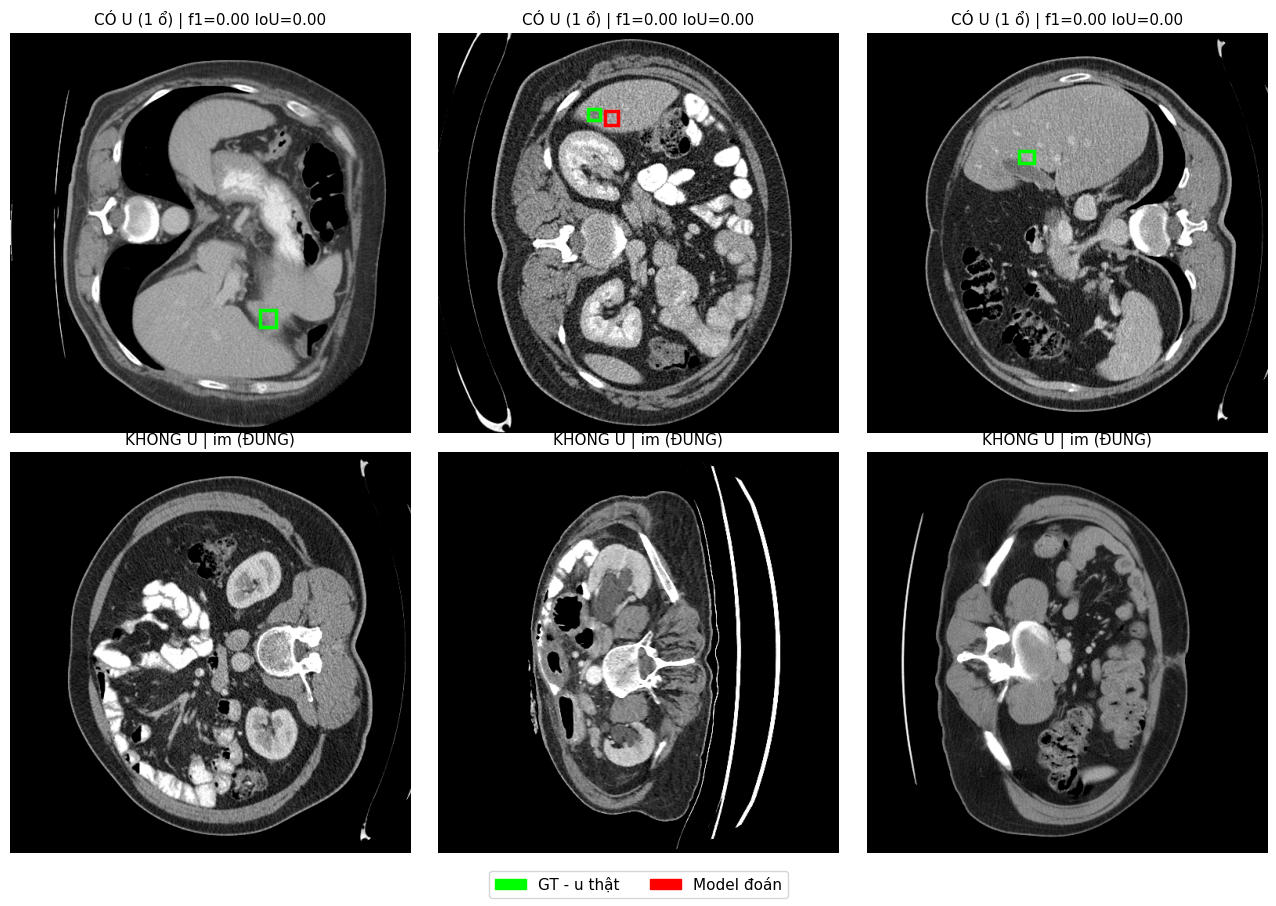

In [18]:
# === [Vẽ] Ảnh + box (MULTI-BOX) — chọn đa dạng bệnh nhân ===
import matplotlib.pyplot as plt, matplotlib.patches as patches
import matplotlib.patches as mpatches, torch, random
from collections import OrderedDict

def _draw_boxes(ax, boxes, color, W, H):
    for box in (boxes or []):
        x1, y1, x2, y2 = (box[0]/COORD_SCALE*W, box[1]/COORD_SCALE*H,
                          box[2]/COORD_SCALE*W, box[3]/COORD_SCALE*H)
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2.5, edgecolor=color, facecolor='none'))

random.seed(0)
def pick(label, n=3):
    by_pat = OrderedDict()
    for r in dataset["test"]:
        if r["label"] == label: by_pat.setdefault(r["patient_id"], r)
    pats = list(by_pat.values()); random.shuffle(pats)
    return pats[:n]
samples = pick("tumor") + pick("none")

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for i, (ax, rec) in enumerate(zip(axes.flat, samples)):
    img = load_image(rec); W, H = img.size
    inputs = build_infer_inputs(rec, processor, device=model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)
    raw = processor.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    preds = parse_boxes(raw); gts = rec.get("gt_boxes") or []
    m = box_metrics(preds, gts)
    print(f"[{i}] pid={rec['patient_id']} | {rec['label']:5} | GT={len(gts)}box pred={len(preds)}box | f1={m['f1']:.2f} miou={m['miou']:.2f}")
    ax.imshow(img); _draw_boxes(ax, gts, "lime", W, H); _draw_boxes(ax, preds, "red", W, H)
    if gts:
        title = f"CÓ U ({len(gts)} ổ) | f1={m['f1']:.2f} IoU={m['miou']:.2f}"
    else:
        title = "KHÔNG U | " + ("im (ĐÚNG)" if not preds else f"BỊA {len(preds)} box")
    ax.set_title(title, fontsize=11); ax.axis("off")
fig.legend(handles=[mpatches.Patch(color="lime", label="GT - u thật"),
                    mpatches.Patch(color="red", label="Model đoán")],
           loc="lower center", ncol=2, fontsize=11)
plt.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()

In [19]:
# === [EVAL] Hàm predict MULTI-BOX + 3 tín hiệu tin cậy ===
import numpy as np, re

USE_MOCK = globals().get("USE_MOCK", False)

if USE_MOCK:
    import hashlib
    def _diff(rec):
        return (int(hashlib.md5(str(rec["id"]).encode()).hexdigest(), 16) % 1000) / 1000.0
    def predict_boxes(rec, temperature=0.0):
        gts = rec.get("gt_boxes") or []
        d = _diff(rec); jit = COORD_SCALE * (0.02 + 0.3 * d) * (1.0 if temperature > 0 else 0.4)
        out = []
        for gv in gts:
            nb = [int(np.clip(gv[i] + np.random.normal(0, jit), 0, COORD_SCALE - 1)) for i in range(4)]
            out.append([min(nb[0], nb[2]), min(nb[1], nb[3]), max(nb[0], nb[2]), max(nb[1], nb[3])])
        return out, float(np.clip(-0.1 - 2.5 * d, -5, 0))
    def gen_raw(rec, temperature=0.0):
        boxes, lp = predict_boxes(rec, temperature)
        toks = [{"tok": str(c), "lp": lp} for b in boxes for c in b]   # giả token chữ số (mock)
        return {"text": str(boxes), "boxes": boxes, "tokens": toks}
    def conf_self(rec):
        return float(np.clip(1 - _diff(rec), 0, 1))
else:
    import torch, torch.nn.functional as F
    @torch.no_grad()
    def _generate(rec, temperature=0.0, prompt=None, max_new=None):
        inp = build_infer_inputs(rec, processor, device=model.device, prompt=prompt)
        gen = model.generate(**inp, max_new_tokens=max_new or MAX_NEW_TOKENS,
                             do_sample=temperature > 0, temperature=max(temperature, 1e-5),
                             output_scores=True, return_dict_in_generate=True)
        new = gen.sequences[0][inp["input_ids"].shape[1]:]
        return new, gen.scores
    def _coord_logprob(new, scores):
        """TB logprob CHỈ trên token là CHỮ SỐ (toạ độ) — bỏ token khuôn mẫu (fix bug -0.865)."""
        lps = []
        for t, sc in zip(new, scores):
            tok = processor.decode([int(t)], skip_special_tokens=True)
            if tok.strip().isdigit():
                lps.append(F.log_softmax(sc[0], -1)[int(t)].item())
        return float(np.mean(lps)) if lps else -10.0
    @torch.no_grad()
    def predict_boxes(rec, temperature=0.0):
        new, scores = _generate(rec, temperature)
        boxes = parse_boxes(processor.decode(new, skip_special_tokens=True))
        return boxes, _coord_logprob(new, scores)
    @torch.no_grad()
    def gen_raw(rec, temperature=0.0):
        """1 lần đoán -> RAW: text + box + TỪNG token kèm logprob (để tính lại/debug trên JSON)."""
        new, scores = _generate(rec, temperature)
        text = processor.decode(new, skip_special_tokens=True)
        toks = [{"tok": processor.decode([int(t)], skip_special_tokens=True),
                 "lp": float(F.log_softmax(sc[0], -1)[int(t)].item())}
                for t, sc in zip(new, scores)]
        return {"text": text, "boxes": parse_boxes(text), "tokens": toks}
    @torch.no_grad()
    def conf_self(rec):
        CONF_PROMPT = ("Look carefully at the liver in this CT image. On a scale of 0 to 100, "
                       "how confident are you that a liver tumor is present? Answer with ONLY one number.")
        new, _ = _generate(rec, prompt=CONF_PROMPT, max_new=8)
        m = re.findall(r"\d+", processor.decode(new, skip_special_tokens=True))
        return min(int(m[0]), 100) / 100.0 if m else 0.5

def _set_iou(A, B):
    """Độ trùng giữa 2 TẬP box (multi-box): tổng matched-IoU / max(số box) — phạt lệch số box."""
    mi, na, nb = match_boxes(A, B)
    # rỗng-rỗng -> 0.0 (KHÔNG 1.0): "nhất quán không vẽ" = sót u nhất quán, KHÔNG phải tự tin ĐỊNH VỊ
    return float(np.sum(mi) / max(na, nb)) if mi else 0.0

def conf_spatial(rec, n=None):
    """n lần đoán -> mỗi lần 1 TẬP box -> nhất quán = mean set-IoU từng cặp lần."""
    n = n or globals().get("N_SAMPLES", 5)
    sets = [predict_boxes(rec, temperature=0.7)[0] for _ in range(n)]
    pair = [_set_iou(sets[i], sets[j]) for i in range(len(sets)) for j in range(i + 1, len(sets))]
    return float(np.mean(pair)) if pair else 0.0

def _logprob_from_tokens(toks, digits_only=True):
    """Tính logprob từ list token raw: digits_only=True -> chỉ token chữ số (toạ độ); False -> mọi token."""
    lps = [t["lp"] for t in toks if ((str(t["tok"]).strip().isdigit()) if digits_only else True)]
    return float(np.mean(lps)) if lps else -10.0
print("gen_raw (lưu text+tokens+box) + _logprob_from_tokens OK | mode:", "MOCK" if USE_MOCK else "REAL")

gen_raw (lưu text+tokens+box) + _logprob_from_tokens OK | mode: REAL


In [20]:
# === [EVAL PREDICT] Đoán test + cal MỘT LẦN -> lưu JSON DUY NHẤT/lần chạy trên Drive (không ghi đè) ===
from tqdm import tqdm
from datetime import datetime
import json as _json, os, torch
torch.manual_seed(globals().get("SEED", 0))            # eval tất định (mỗi ảnh đoán N_PRED lần)
if not globals().get("USE_MOCK", False):               # generate PHẢI dùng KV-cache -> nhanh
    model.config.use_cache = True; model.eval()         # (train tắt use_cache; không bật lại sẽ chậm 5-10x)
EVAL_LIMIT = globals().get("EVAL_LIMIT", None)
CAL_LIMIT  = globals().get("CAL_LIMIT", None)          # None = HẾT cal+ (103 lát/21 bệnh nhân). 60 chỉ phủ 13 bn -> lệch

N_PRED = globals().get("N_PRED", 3)            # số lần đoán/ảnh (lần 1 greedy=CHÍNH; lần 2-3 sampled)
def _predict_row(rec):
    gens = [gen_raw(rec, 0.0)]                  # lần 1: GREEDY = đáp án CHÍNH
    for _ in range(N_PRED - 1):
        gens.append(gen_raw(rec, 0.7))         # lần 2-3: SAMPLED
    g0 = gens[0]
    return {"pid": rec["patient_id"], "rec": rec,
            "gt_boxes": rec.get("gt_boxes") or [], "is_pos": bool(rec.get("gt_boxes")),
            "pred_boxes": g0["boxes"],          # tiện cho cell METRICS (box CHÍNH = lần 1)
            "logprob": _logprob_from_tokens(g0["tokens"], True),   # tiện: digit-only lần 1 (tính lại được từ gens)
            "gens": gens}                        # RAW ĐẦY ĐỦ: text + tokens(lp) + boxes MỖI lần -> debug/tính lại

_test = dataset["test"][:EVAL_LIMIT] if EVAL_LIMIT else dataset["test"]
_calp = [r for r in dataset["cal"] if r.get("gt_boxes")]
_calp = _calp[:CAL_LIMIT] if CAL_LIMIT else _calp
rows_eval = [_predict_row(r) for r in tqdm(_test, desc="PREDICT test")]
cal_eval  = [_predict_row(r) for r in tqdm(_calp, desc="PREDICT cal+")]

# --- lưu JSON: TÊN DUY NHẤT mỗi lần chạy (timestamp) -> KHÔNG ghi đè lần trước ---
RUN_NAME = globals().get("RUN_NAME", "gemma4_v3")            # tên lần train (từ cfg)
EVAL_DIR = os.path.join(CKPT_DIR, "eval_runs"); os.makedirs(EVAL_DIR, exist_ok=True)
out_json = os.path.join(EVAL_DIR, f"eval_pred_{RUN_NAME}_{datetime.now().strftime('%m%d_%H%M%S')}.json")  # +timestamp -> không ghi đè
def _clean(rows): return [{k: v for k, v in r.items() if k != "rec"} for r in rows]
payload = {"run": RUN_NAME, "n_test": len(rows_eval), "n_cal": len(cal_eval),
           "test": _clean(rows_eval), "cal": _clean(cal_eval)}
with open(out_json, "w") as f:                          # context manager -> flush/đóng đúng (Drive)
    _json.dump(payload, f)
assert os.path.exists(out_json) and os.path.getsize(out_json) > 100, "JSON rỗng / chưa ghi được!"
with open(out_json) as f:                               # đọc lại verify hợp lệ
    _chk = _json.load(f); assert len(_chk["test"]) == len(rows_eval)
print(f"PREDICT xong | test {len(rows_eval)} ({sum(r['is_pos'] for r in rows_eval)} dương) | cal+ {len(cal_eval)}")
print(f"Lưu JSON (Drive, tên riêng lần này): {out_json} ({os.path.getsize(out_json)/1e6:.2f} MB) — verify OK")

PREDICT cal+: 100%|██████████| 103/103 [17:05<00:00,  9.96s/it]

PREDICT xong | test 255 (120 dương) | cal+ 103
Lưu JSON (Drive, tên riêng lần này): /content/drive/MyDrive/Colab Notebooks/medrega/model/checkpoints/eval_runs/eval_pred_gemma4_v4_binary_loss_0629_145106.json (1.10 MB) — verify OK


In [21]:
# === [TÙY CHỌN — Mode C] Nạp JSON dự đoán CÓ SẴN -> CHỈ phân tích (KHÔNG cần GPU/train/predict) ===
# Khi đã có file eval_pred_*.json: ĐẶT đường dẫn bên dưới, chạy cell này THAY cho cell PREDICT,
# rồi chạy 2 cell METRICS + HƯỚNG-1. (Chỉ cần chạy thêm cell imports + util phía trên — chạy CPU cũng được.)
LOAD_JSON_PATH = ""   # vd "/content/drive/MyDrive/Colab Notebooks/medrega/model/checkpoints/eval_runs/eval_pred_gemma4_v3_0628_050605.json"
if LOAD_JSON_PATH:
    import json as _json
    _d = _json.load(open(LOAD_JSON_PATH))
    rows_eval = _d["test"]; cal_eval = _d["cal"]
    print(f"Nạp JSON: test {len(rows_eval)} | cal {len(cal_eval)} | run {_d.get('run')}")
else:
    print("LOAD_JSON_PATH rỗng -> bỏ qua (đang train/eval bình thường, dùng rows_eval từ PREDICT).")

LOAD_JSON_PATH rỗng -> bỏ qua (đang train/eval bình thường, dùng rows_eval từ PREDICT).


In [22]:
# === [EVAL METRICS] Multi-box Hungarian: recall/precision@IoU + mean-IoU + per-patient + phân tầng + CI ===
import numpy as np
from collections import defaultdict
THRS = [0.1, 0.25, 0.5, 0.75]

for r in rows_eval:                         # mean matched-IoU mỗi lát
    r["matched"] = match_boxes(r["pred_boxes"], r["gt_boxes"])[0]
    r["miou"] = float(np.mean(r["matched"])) if r["matched"] else 0.0

pos = [r for r in rows_eval if r["is_pos"]]
neg = [r for r in rows_eval if not r["is_pos"]]

def micro_recall_prec(rows, th):
    tp = sum(sum(v > th for v in r["matched"]) for r in rows)
    ngt = sum(len(r["gt_boxes"]) for r in rows)
    npr = sum(len(r["pred_boxes"]) for r in rows)
    return (tp / ngt if ngt else 0.0, tp / npr if npr else 0.0)

def _pen_iou(r):                            # mẫu số = max(số ổ GT, số box đoán) -> PHẠT thiếu/thừa box
    d = max(len(r["gt_boxes"]), len(r["pred_boxes"]));  return (sum(r["matched"]) / d) if d else 0.0
print(f"[per-slice DƯƠNG] {len(pos)} lát | IoU(cặp ghép) {np.mean([r['miou'] for r in pos]):.3f}"
      f" | IoU(phạt thiếu box) {np.mean([_pen_iou(r) for r in pos]):.3f}")
print("   (recall = % ổ u bắt được; precision = % box đoán đúng)")
for th in THRS:
    rc, pr = micro_recall_prec(pos, th)
    print(f"   @IoU>{th}: recall {rc:.0%} | precision {pr:.0%}")

# per-patient (đơn vị độc lập)
by_pat = defaultdict(list)
for r in pos: by_pat[r["pid"]].append(r)
pat_iou = np.array([np.mean([r["miou"] for r in rs]) for rs in by_pat.values()])
print(f"\n[PER-PATIENT] {len(by_pat)} bệnh nhân dương | mean-IoU {pat_iou.mean():.3f}")
for th in [0.25, 0.5]:
    print(f"   bệnh nhân IoU-TB >= {th}: {(pat_iou >= th).mean():.0%}")

def boot_ci(vals, n=2000):
    vals = np.asarray(vals, float)
    if len(vals) < 2: return (float("nan"), float("nan"))
    idx = np.arange(len(vals))
    rng = np.random.default_rng(0)
    ms = [vals[rng.choice(idx, len(idx), replace=True)].mean() for _ in range(n)]
    return tuple(np.percentile(ms, [2.5, 97.5]))
lo, hi = boot_ci(pat_iou)
print(f"   CI95 (bootstrap theo bệnh nhân): [{lo:.3f}, {hi:.3f}]")

# phân tầng 1-ổ vs nhiều-ổ (độ khó)
single = [r["miou"] for r in pos if len(r["gt_boxes"]) == 1]
multi  = [r["miou"] for r in pos if len(r["gt_boxes"]) >= 2]
print(f"\n[Phân tầng] 1-ổ: {len(single)} lát, mean-IoU {np.mean(single) if single else 0:.3f}"
      f" | nhiều-ổ: {len(multi)} lát, mean-IoU {np.mean(multi) if multi else 0:.3f}")

# === [NHẬN BIẾT có/không u] phân loại nhị phân: VẼ BOX hay KHÔNG — TÁCH khỏi IoU ===
def _detect_report(rows, level):
    if level == "patient":
        bp = defaultdict(lambda: [0, 0])
        for r in rows:
            bp[r["pid"]][0] |= int(bool(r["gt_boxes"])); bp[r["pid"]][1] |= int(len(r["pred_boxes"]) > 0)
        items = list(bp.values())
    else:
        items = [[int(bool(r["gt_boxes"])), int(len(r["pred_boxes"]) > 0)] for r in rows]
    TP = sum(g and p for g, p in items); FP = sum((not g) and p for g, p in items)
    TN = sum((not g) and not p for g, p in items); FN = sum(g and not p for g, p in items); n = len(items)
    sens = TP/(TP+FN) if TP+FN else 0; spec = TN/(TN+FP) if TN+FP else 0
    prec = TP/(TP+FP) if TP+FP else 0; f1 = 2*prec*sens/(prec+sens) if prec+sens else 0
    print(f"  [{level}] n={n} TP={TP} FP={FP} TN={TN} FN={FN} | "
          f"Sens(bắt u) {sens:.0%} | Spec(loại sạch) {spec:.0%} | Prec {prec:.0%} | F1 {f1:.2f}")
print("")
print("[NHẬN BIẾT có/không u] — chỉ xét VẼ BOX hay KHÔNG, ĐỘC LẬP IoU:")
_detect_report(rows_eval, "slice"); _detect_report(rows_eval, "patient")

# ca ÂM: bịa box (FP) — phần thêm của mình, paper không có
if neg:
    fp = sum(len(r["pred_boxes"]) > 0 for r in neg)
    print(f"\n[ÂM per-slice] {len(neg)} lát | im đúng {len(neg)-fp} | BỊA box (FP) {fp} ({fp/len(neg):.0%})")
    nbp = defaultdict(list)                 # per-patient (đơn vị độc lập, đúng quy ước per-patient)
    for r in neg: nbp[r["pid"]].append(r)
    pat_fp = np.array([any(len(x["pred_boxes"]) > 0 for x in rs) for rs in nbp.values()], float)
    flo, fhi = boot_ci(pat_fp)
    print(f"[ÂM per-patient] {len(nbp)} bệnh nhân có lát âm | có >=1 FP: {pat_fp.mean():.0%} | CI95 [{flo:.2f}, {fhi:.2f}]")
    print("   (lưu ý: lát âm từ bệnh nhân CÓ u -> đây là phân biệt lát-có/không-u, KHÔNG phải specificity lâm sàng)")

[per-slice DƯƠNG] 120 lát | IoU(cặp ghép) 0.073 | IoU(phạt thiếu box) 0.061
   (recall = % ổ u bắt được; precision = % box đoán đúng)
   @IoU>0.1: recall 20% | precision 24%
   @IoU>0.25: recall 10% | precision 11%
   @IoU>0.5: recall 1% | precision 2%
   @IoU>0.75: recall 0% | precision 0%

[PER-PATIENT] 25 bệnh nhân dương | mean-IoU 0.071
   bệnh nhân IoU-TB >= 0.25: 12%
   bệnh nhân IoU-TB >= 0.5: 0%
   CI95 (bootstrap theo bệnh nhân): [0.036, 0.114]

[Phân tầng] 1-ổ: 85 lát, mean-IoU 0.075 | nhiều-ổ: 35 lát, mean-IoU 0.070

[ÂM per-slice] 135 lát | im đúng 127 | BỊA box (FP) 8 (6%)
[ÂM per-patient] 27 bệnh nhân có lát âm | có >=1 FP: 26% | CI95 [0.11, 0.44]
   (lưu ý: lát âm từ bệnh nhân CÓ u -> đây là phân biệt lát-có/không-u, KHÔNG phải specificity lâm sàng)


In [23]:
# === [EVAL theo KÍCH THƯỚC u] recall/IoU theo diện tích GT box (proxy độ to/rõ của u) ===
# Giải thích recall thấp: model sót u NHỎ (mờ) hay sót cả u to? Chạy được cả Mode C (chỉ cần rows_eval + iou).
import numpy as np
pos = [r for r in rows_eval if r["is_pos"]]
lesions = []                                    # (diện tích box [0,1000]^2, best-IoU với pred)
for r in pos:
    for gv in r["gt_boxes"]:
        best = max((iou(p, gv) for p in r["pred_boxes"]), default=0.0)
        lesions.append(((gv[2] - gv[0]) * (gv[3] - gv[1]), best))
A = np.array([a for a, _ in lesions], float); B = np.array([b for _, b in lesions], float)
print(f"Tổng {len(lesions)} ổ u (GT). Diện tích box (% ảnh): "
      f"nhỏ nhất {A.min()/1e4:.2f}% | trung vị {np.median(A)/1e4:.2f}% | to nhất {A.max()/1e4:.2f}%")
q1, q2 = np.percentile(A, [33, 67])
print(f"\n{'Nhóm u':18}{'n':>5}{'recall@.25':>12}{'recall@.5':>11}{'IoU TB':>9}")
for name, lo, hi in [("NHỎ/mờ", A.min() - 1, q1), ("VỪA", q1, q2), ("LỚN/rõ", q2, A.max() + 1)]:
    m = (A >= lo) & (A < hi)
    if not m.any(): continue
    bb = B[m]
    print(f"{name:18}{int(m.sum()):>5}{(bb > 0.25).mean():>12.0%}{(bb > 0.5).mean():>11.0%}{bb.mean():>9.3f}")
print("\n(area %ảnh = area/10000; recall@.25 = % ổ có pred trùng IoU>0.25; best-IoU mỗi ổ với pred gần nhất)")
print("=> Nếu recall NHỎ << recall LỚN: model sót chủ yếu u nhỏ/mờ (khó, bác sĩ cũng khó) — đưa vào Limitations.")

Tổng 206 ổ u (GT). Diện tích box (% ảnh): nhỏ nhất 0.01% | trung vị 0.14% | to nhất 7.03%

Nhóm u                n  recall@.25  recall@.5   IoU TB
NHỎ/mờ               68          1%         0%    0.015
VỪA                  70          9%         1%    0.051
LỚN/rõ               68         19%         3%    0.110

(area %ảnh = area/10000; recall@.25 = % ổ có pred trùng IoU>0.25; best-IoU mỗi ổ với pred gần nhất)
=> Nếu recall NHỎ << recall LỚN: model sót chủ yếu u nhỏ/mờ (khó, bác sĩ cũng khó) — đưa vào Limitations.


=== CAL (chọn tín hiệu — KHÔNG nhìn test) ===
tín hiệu    Spearman  AUROC@.25
logprob       +0.582      0.711
logprob_all    -0.661      0.895
spatial       +0.655      1.000
=> BEST (|Spearman| trên cal): logprob_all

=== TEST (risk-coverage per-patient) ===


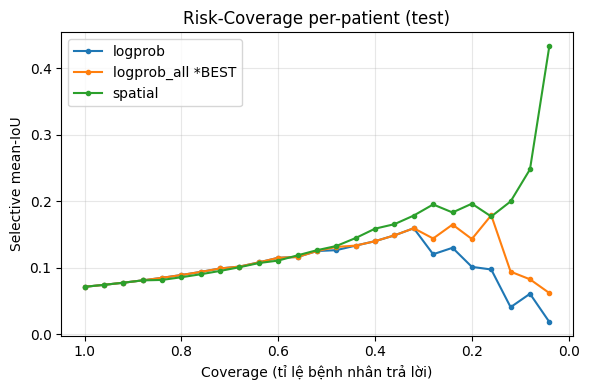

[logprob_all] Coverage 100%: selIoU = 0.071
[logprob_all] Coverage 75%: selIoU = 0.099
[logprob_all] Coverage 50%: selIoU = 0.131
[logprob_all] Coverage 25%: selIoU = 0.165

Ngưỡng conformal (cal, cov~70%): 0.291
TEST: trả lời 15/25 | im 10 | trong số trả lời SAI 15 | selIoU 0.115 | Cost 1.200
(n nhỏ ~ 25 bệnh nhân -> Hướng-1 là PILOT, kèm caveat khi báo cáo)


In [24]:
# === [EVAL HƯỚNG-1] Selective prediction: CAL chọn tín hiệu+ngưỡng, TEST báo cáo, vẽ CẢ 3 ===
import numpy as np, matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
IOU_CORRECT = globals().get("IOU_CORRECT", 0.5); COST_WRONG = 2.0; TARGET_COVERAGE = 0.7
SIGNALS = ["logprob", "logprob_all", "spatial"]   # logprob (chỉ chữ số) vs logprob_all (MỌI token) -> DEBUG cú lật dấu

def _spatial_from_gens(gens):
    """Nhất quán không gian = TB set-IoU từng cặp lần đoán (rỗng-rỗng = 0, không thưởng sót-nhất-quán)."""
    sets = [g.get("boxes", []) for g in gens]
    pair = []
    for i in range(len(sets)):
        for j in range(i + 1, len(sets)):
            mi, na, nb = match_boxes(sets[i], sets[j])
            pair.append(float(np.sum(mi) / max(na, nb)) if mi else 0.0)
    return float(np.mean(pair)) if pair else 0.0
def _lp_from_tokens(toks, digits_only=True):
    lps = [t["lp"] for t in toks if ((str(t["tok"]).strip().isdigit()) if digits_only else True)]
    return float(np.mean(lps)) if lps else -10.0
for r in rows_eval + cal_eval:              # TÍNH SAU từ raw gens (JSON cũ không gens -> fallback số đã lưu)
    g0 = (r.get("gens") or [{}])[0]; toks = g0.get("tokens")
    if toks is not None:
        r["logprob"]     = _lp_from_tokens(toks, True)    # chỉ token chữ số (toạ độ)
        r["logprob_all"] = _lp_from_tokens(toks, False)   # MỌI token (bản cũ nghi bug)
    else:
        r["logprob_all"] = r.get("logprob", -10.0)
    r["spatial"] = _spatial_from_gens(r["gens"]) if r.get("gens") else r.get("spatial", 0.0)

for r in cal_eval:                          # bảo đảm miou có trên cal
    mm = match_boxes(r["pred_boxes"], r["gt_boxes"])[0]
    r["miou"] = float(np.mean(mm)) if mm else 0.0

def per_patient(rows):
    bp = defaultdict(list)
    for r in rows:
        if r["is_pos"]: bp[r["pid"]].append(r)
    piou = np.array([np.mean([r["miou"] for r in rs]) for rs in bp.values()])
    psig = {k: np.array([np.mean([r[k] for r in rs]) for rs in bp.values()]) for k in SIGNALS}
    return piou, psig

T_iou, T_sig = per_patient(rows_eval)       # TEST
C_iou, C_sig = per_patient(cal_eval)        # CAL

# --- CHỌN trên CAL: tín hiệu + dấu (flip per-signal) + ---
print("=== CAL (chọn tín hiệu — KHÔNG nhìn test) ===")
print(f"{'tín hiệu':10}{'Spearman':>10}{'AUROC@.25':>11}")
chosen = {}
c25 = (C_iou >= 0.25).astype(int)
for k in SIGNALS:
    v = C_sig[k]
    rho = spearmanr(v, C_iou).correlation if np.std(v) > 1e-9 and np.std(C_iou) > 1e-9 else float("nan")
    sign = -1.0 if (not np.isnan(rho) and rho < 0) else 1.0           # flip per-signal
    auc = roc_auc_score(c25, sign * v) if len(set(c25)) > 1 and np.std(v) > 1e-9 else float("nan")
    chosen[k] = {"sign": sign, "rho": rho, "auc": auc}
    print(f"{k:10}{rho:>+10.3f}{auc:>11.3f}")
valid = [k for k in SIGNALS if not np.isnan(chosen[k]["rho"])]
BEST = max(valid, key=lambda k: abs(chosen[k]["rho"])) if valid else "spatial"
print(f"=> BEST (|Spearman| trên cal): {BEST}")

# --- TEST: risk-coverage CẢ 3 tín hiệu ---
print("\n=== TEST (risk-coverage per-patient) ===")
n = len(T_iou); plt.figure(figsize=(6, 4))
for k in SIGNALS:
    sig = chosen[k]["sign"] * T_sig[k]; order = np.argsort(-sig)
    cov = [(i + 1) / n for i in range(n)]; sel = [T_iou[order[:i + 1]].mean() for i in range(n)]
    plt.plot(cov, sel, marker="o", ms=3, label=k + (" *BEST" if k == BEST else ""))
plt.gca().invert_xaxis(); plt.xlabel("Coverage (tỉ lệ bệnh nhân trả lời)")
plt.ylabel("Selective mean-IoU"); plt.title("Risk-Coverage per-patient (test)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
sig = chosen[BEST]["sign"] * T_sig[BEST]; order = np.argsort(-sig)
for c in [1.0, .75, .5, .25]:
    kk = max(1, int(c * n)); print(f"[{BEST}] Coverage {c:.0%}: selIoU = {T_iou[order[:kk]].mean():.3f}")

# --- Conformal: ngưỡng đặt trên CAL, áp TEST ---
csig = chosen[BEST]["sign"] * C_sig[BEST]
thr = float(np.quantile(csig, 1 - TARGET_COVERAGE))
tsig = chosen[BEST]["sign"] * T_sig[BEST]
ans = tsig >= thr; selia = T_iou[ans]; wrong = int(np.sum(selia < IOU_CORRECT))
print(f"\nNgưỡng conformal (cal, cov~{TARGET_COVERAGE:.0%}): {thr:.3f}")
print(f"TEST: trả lời {int(ans.sum())}/{n} | im {int((~ans).sum())} | trong số trả lời SAI {wrong} | "
      f"selIoU {np.mean(selia) if len(selia) else float('nan'):.3f} | Cost {wrong*COST_WRONG/max(n,1):.3f}")
print("(n nhỏ ~", n, "bệnh nhân -> Hướng-1 là PILOT, kèm caveat khi báo cáo)")

In [ ]:
# === Ngắt + xoá runtime Colab (dừng đốt CU). Chạy SAU KHI đã lưu xong. ===
from google.colab import runtime
runtime.unassign()